In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import constants as CONSTANTS

# Evaluation de TP
Auteur : SINEYEN Amritesh
Date : 19/05/2026

Déclaration des constantes

In [29]:
m_terre = 5.9712E24
m_sun = 1.9847E30

au = CONSTANTS.astronomical_unit
pi = CONSTANTS.pi
grav = CONSTANTS.gravitational_constant
an = CONSTANTS.year

## 1. RK4 vectorielle

In [30]:
def v_RK4(f, t0, y0, tf, N):
    t, h = np.linspace(t0,tf,N+1,retstep=True)
    y = np.zeros( (N+1, np.size(y0)))
    y[0] = y0

    for n in range(N):

        k1 = f(t[n],y[n])
        k2 = f(t[n] + h/2, y[n]+ h/2*k1)
        k3 = f(t[n] + h/2, y[n]+ h/2*k2)
        k4 = f(t[n] + h, y[n]+ h*k3)
        y[n+1] = y[n] + h/6 *(k1+2* k2+2 *k3+k4 )

    return t, y

In [31]:
def v_euleur(f,t0,y0,tf,N):
    t, h = np.linspace(t0,tf,N+1,retstep=True)
    y = np.zeros( (N+1, np.size(y0)))
    y[0] = y0

    for n in range(N):
        y[n+1] = y[n]+ h * f(t[n],y[n])

    return t, y

## 2. FKepler(t,Y)

Soit $Y = (x,y,v_x,v_y)$

La fonction retourne : 
$(v_x,v_y,a_x,a_y)$

Où $$ ax = \frac{dv_x}{dt} = - \frac{GMx}{(x^2 + y^2)^{3/2}} $$
$$ ay = \frac{dv_x}{dt} = - \frac{GMy}{(x^2 + y^2)^{3/2}} $$

Avec : 
- G : constante gravitationelle 
- M : masse de la terre

In [40]:
def FKepler(t,Y):
    x = Y[0]
    y = Y[1]
    vx = Y[2]
    vy = Y[3]

    ax = -( (grav*m_terre*x) / ( (x*x + y*y)**(1.5) ) )
    ay = -( (grav*m_terre*y) / ( (x**2 + y**2)**(1.5) ) )
    return np.array([ vx, vy, ax, ay])

## 3. Initialisation de $Y_0$

Soit $Y = (x,y,v_x,v_y)$

$$ Y_0 = (1.067 * AU, 0, 0, 29.2910^3 ) $$
Où :
- AU : unitée astronomique

In [41]:
x0 = 1.0167*au
y0 = 0
vx0 = 0
vy0 = 29.29* (10**3)

Y0 = np.array([x0,y0,vx0,vy0])

## 4. & 5. Resolution de l'EDO et tracer de la figure  

Il y a un problème quelque part qui n'as pas été, même par l'enseignant.

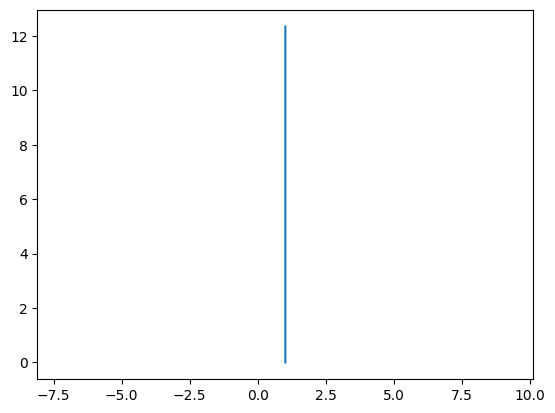

In [44]:
t0 = 0
n_years = t0 + 2 * an

t, y_trace = v_RK4(FKepler,t0,Y0,n_years,10000)

fig, ax = plt.subplots()

ax.plot(y_trace[:,0]/au,y_trace[:,1]/au)

ax.axis('equal')

plt.show()

# 6. Vitesse en fonction du temps
Soit le module de la vitesse : 
$$ \|v \| = \sqrt{v_x^2 + v_y^2} $$

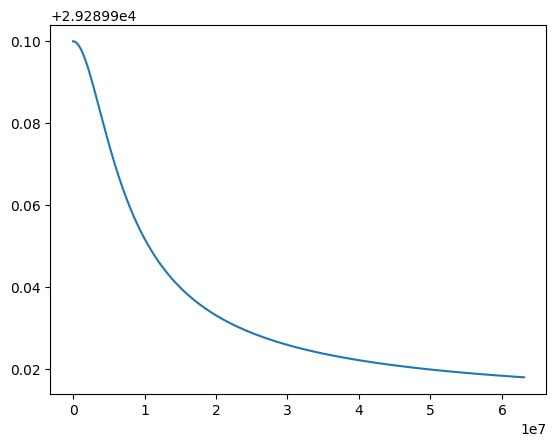

In [35]:
fig, ax = plt.subplots()

module_v = np.sqrt(y_trace[:,2]**2 + y_trace[:,3]**2)
ax.plot(t,module_v)

plt.show()

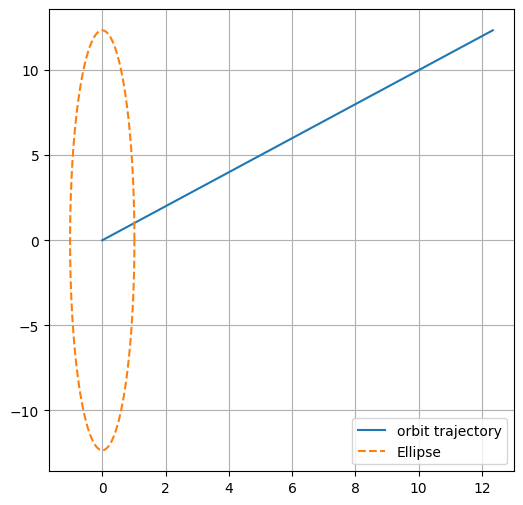

In [38]:
x, y = y_trace[:,0], y_trace[:,1]

ah = Y0[0] / au
ph = abs(np.min(x)/au)
a = (ah+ph)/2
b = np.max(y)/au
c = a- ph 

fig, ax = plt.subplots(figsize = [6,6])
ax.plot(y/au,y/au,label='orbit trajectory')
theta = np.linspace(0,2 * np.pi,100)
X = a*np.cos(theta)+c
Y = b*np.sin(theta)
ax.plot(X,Y,'--',label = "Ellipse")
ax.legend()
ax.grid()
plt.show()